# 01 — Diagnóstico de Missingness

## Objetivo

Identifica y clasifica todos los valores faltantes del dataset (tanto `NaN` reales como valores codificados como string), y asigna una estrategia de imputación justificada por columna.

---

## Precondición

El notebook opera sobre el dataset crudo:

```text
data/dataset.csv
```

Filtrando únicamente registros de nivel universitario (`AD14–AD20`).

---

## Hallazgo crítico (leer antes de continuar)

El dataset NO usa `NaN` para la mayoría de los valores faltantes.

Usa strings codificados:

```python id="2exkec"
'No information'
'Does not apply'
'Does not apply '
```

Esto significa que columnas que parecen completas (`0% NaN`) en realidad tienen hasta `85%` de datos faltantes.

El primer paso del pipeline es normalizar estos valores a `NaN` real.

## 0. Setup

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

# missingno para heatmap de nulos
try:
    import missingno as msno
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'missingno', '-q'])
    import missingno as msno

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.max_rows', 80)
pd.set_option('display.float_format', '{:.2f}'.format)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PALETTE = {'pretec21': '#2471A3', 'tec21': '#1A7A5E', 'missing': '#C0392B', 'ok': '#27AE60'}

## 1. Carga y filtrado inicial

In [17]:
# Ruta relativa desde la raíz del repositorio 
RAW_PATH = '../dataset.csv'

df_raw = pd.read_csv(RAW_PATH)
print(f'Dataset crudo: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas')
print(f'Niveles en `school`: {df_raw["school"].unique().tolist()}')

Dataset crudo: 143,326 filas × 50 columnas
Niveles en `school`: ['High school', 'EN', 'EIC', 'EHE-EAAD', 'EMCS', 'ECSG', 'EAAD-Engineering and Sciences']


In [18]:
# Filtrar solo nivel universitario 
df = df_raw[df_raw['school'] != 'High school'].copy()
df = df.reset_index(drop=True)

# Mapear educational.model a etiqueta legible
# 0 = Pre-TEC21 (AD14-AD18), 1 = TEC21 (AD19-AD20)
df['regime'] = df['educational.model'].map({0: 'PreTec21', 1: 'Tec21'})

n_pretec = (df['regime'] == 'PreTec21').sum()
n_tec    = (df['regime'] == 'Tec21').sum()

print(f'Dataset universitario: {len(df):,} filas × {df.shape[1]} columnas')
print(f'  PreTec21 (AD14-18): {n_pretec:,} ({n_pretec/len(df)*100:.1f}%)')
print(f'  Tec21    (AD19-20): {n_tec:,}  ({n_tec/len(df)*100:.1f}%)')
print(f'\nTasa de deserción (retention=0): {(df["retention"]==0).mean()*100:.1f}%')

Dataset universitario: 77,517 filas × 51 columnas
  PreTec21 (AD14-18): 53,010 (68.4%)
  Tec21    (AD19-20): 24,507  (31.6%)

Tasa de deserción (retention=0): 8.8%


## 2. Selección de columnas relevantes para el análisis

De las 50 columnas del dataset crudo, seleccionamos las variables que entran al pipeline de modelado. Se excluyen:
- Identificadores (`student.id`, `generation`)
- Variables de resultado que no están disponibles al inicio del semestre (`dropout.semester`, `FTE`)
- Variables de desempeño académico final que contaminarían el early warning (`failed.subject.first.period`, `dropped.subject.first.period`)
- Columnas con >95% de datos faltantes tras normalización (se evalúan en la sección 4)

In [19]:
# Columnas que entran al análisis de missingness
COLS_ANALYSIS = [
    # Demográficas / perfil de entrada
    'gender', 'age', 'foreign', 'zone.type', 'region',
    'tec.no.tec',
    # Educación familiar
    'first.generation', 'max.degree.parents',
    'parents.exatec',
    # Socioeconómicas
    'socioeconomic.level', 'social.lag',
    # Admisión
    'PNA', 'admission.test', 'english.evaluation',
    'general.math.eval', 'admission.rubric', 'online.test',
    # Financieras
    'scholarship.perc', 'scholarship.type', 'loan.perc', 'total.scholarship.loan',
    # Vida universitaria
    'total.life.activities', 'physical.education',
    # Institución
    'school', 'program', 'school.cost',
    # Solo TEC21
    'average.first.period',
    # Target
    'retention',
    # Auxiliar (no entra al modelo)
    'regime',
]

df_sel = df[COLS_ANALYSIS].copy()
print(f'Columnas seleccionadas para análisis: {len(COLS_ANALYSIS)}')

Columnas seleccionadas para análisis: 29


## 3. Normalización de valores faltantes codificados como string

El dataset codifica los faltantes como strings (`'No information'`, `'Does not apply'`, etc.) en lugar de `NaN`. Esto significa que `.isnull()` no los detecta y los modelos los tratarían como categorías válidas, introduciendo sesgo.

Convertimos todos los valores codificados a `NaN` real antes de cualquier análisis. 

In [20]:
# Strings que el dataset usa para indicar ausencia de dato
ENCODED_MISSING = {
    'No information',
    'Does not apply',
    'Does not apply ',   
    'does not apply',
    'N/A',
    '',
}

def normalize_missing(df: pd.DataFrame) -> pd.DataFrame:
    #Reemplazar con NaN sin modificar el DataFrame original
    df = df.copy()
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].apply(
            lambda x: np.nan if (isinstance(x, str) and x.strip() in ENCODED_MISSING) else x
        )
    return df

df_clean = normalize_missing(df_sel)

# Comparar conteo antes vs después
nan_before = df_sel.isnull().sum().sum()
nan_after  = df_clean.isnull().sum().sum()
print(f'NaN antes de normalización : {nan_before:,}')
print(f'NaN después de normalización: {nan_after:,}')
print(f'Valores faltantes descubiertos: {nan_after - nan_before:,}')

NaN antes de normalización : 83,492
NaN después de normalización: 472,142
Valores faltantes descubiertos: 388,650


In [21]:
# Convertir columnas numéricas que llegaron como string
# admission.test y general.math.eval llegaron como object por los encoded missing
NUMERIC_FROM_STRING = ['admission.test', 'general.math.eval']

for col in NUMERIC_FROM_STRING:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
    print(f'{col}: convertido a numeric. NaN resultantes: {df_clean[col].isnull().sum():,}')

admission.test: convertido a numeric. NaN resultantes: 25,255
general.math.eval: convertido a numeric. NaN resultantes: 7,847


## 4. Diagnóstico de missingness por columna

In [22]:
# Tabla completa de missingness
def missingness_report(df: pd.DataFrame, regime_col: str = 'regime') -> pd.DataFrame:
    rows = []
    pretec = df[df[regime_col] == 'PreTec21']
    tec    = df[df[regime_col] == 'Tec21']

    for col in df.columns:
        if col in [regime_col, 'retention']:
            continue
        n_total   = df[col].isnull().sum()
        n_pretec  = pretec[col].isnull().sum()
        n_tec     = tec[col].isnull().sum()
        rows.append({
            'columna'       : col,
            'dtype'         : str(df[col].dtype),
            'n_faltante'    : n_total,
            'pct_global'    : round(n_total / len(df) * 100, 1),
            'pct_pretec21'  : round(n_pretec / len(pretec) * 100, 1),
            'pct_tec21'     : round(n_tec / len(tec) * 100, 1),
        })

    report = pd.DataFrame(rows).sort_values('pct_global', ascending=False)
    return report.reset_index(drop=True)

report = missingness_report(df_clean)
print(report.to_string(index=False))

               columna   dtype  n_faltante  pct_global  pct_pretec21  pct_tec21
   socioeconomic.level  object       66446       85.70        100.00      54.80
            social.lag  object       63984       82.50        100.00      44.80
             zone.type  object       54718       70.60        100.00       7.00
  average.first.period float64       53010       68.40        100.00       0.00
 total.life.activities  object       41824       54.00         78.70       0.40
      first.generation  object       37372       48.20         70.40       0.20
    physical.education  object       36361       46.90         22.40     100.00
    max.degree.parents  object       35255       45.50         66.40       0.20
      admission.rubric float64       29851       38.50         46.00      22.30
        admission.test float64       25255       32.60         34.20      29.10
        parents.exatec  object       20219       26.10         38.00       0.30
     general.math.eval float64        78

## 5. Visualización — Heatmap de missingness

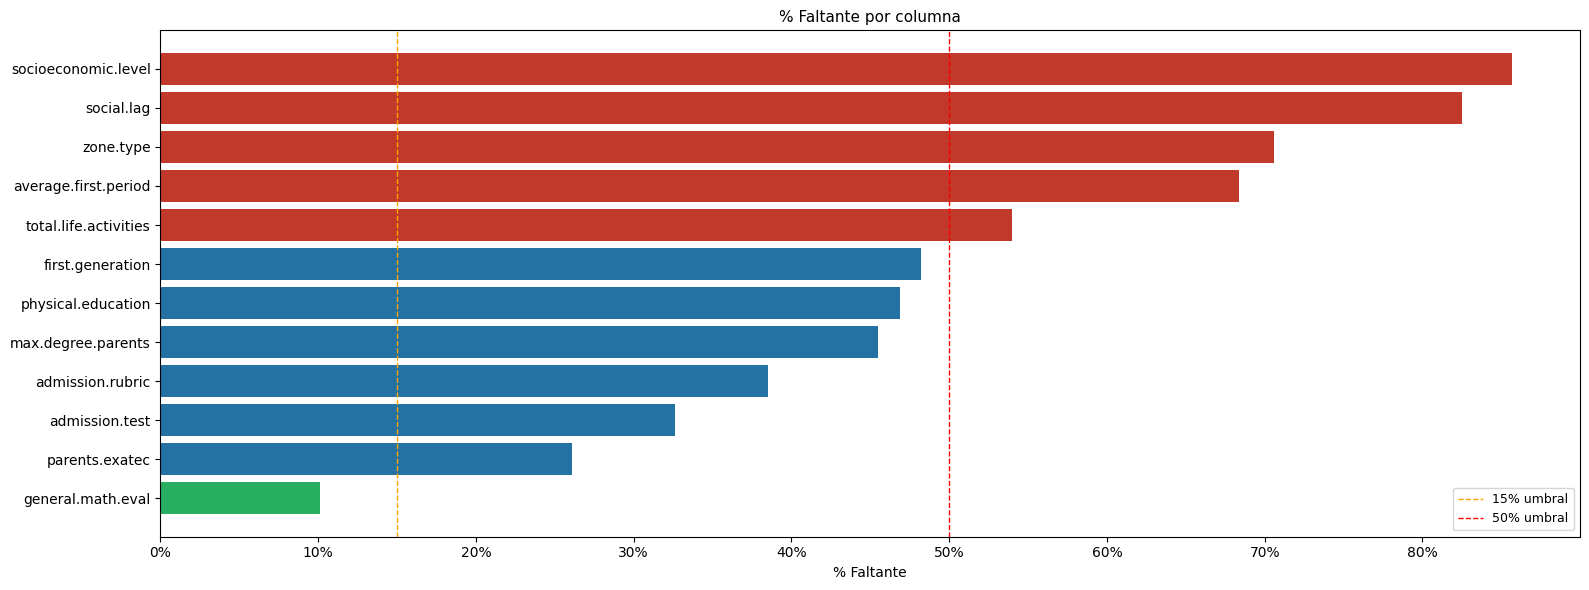

In [23]:
# Columnas con al menos 1% de faltantes
cols_with_missing = report[report['pct_global'] >= 1]['columna'].tolist()

fig, ax = plt.subplots(figsize=(16, 6))

# Bar chart: % faltante por columna
sorted_report = report[report['pct_global'] > 0].sort_values('pct_global')

colors = [
    PALETTE['missing'] if p >= 50 else '#2471A3' if p >= 15 else '#27AE60'
    for p in sorted_report['pct_global']
]

ax.barh(sorted_report['columna'], sorted_report['pct_global'], color=colors)

ax.axvline(15, color='orange', linestyle='--', linewidth=1, label='15% umbral')
ax.axvline(50, color='red', linestyle='--', linewidth=1, label='50% umbral')

ax.set_xlabel('% Faltante')
ax.set_title('% Faltante por columna', fontsize=11)

ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()

plt.savefig(
    '../../results/figures/missingness_heatmap.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

## 6. Clasificación MCAR / MAR / MNAR por columna

La clasificación se basa en tres criterios:

| Tipo | Criterio operacional |
|------|----------------------|
| **MCAR** | La probabilidad de que el dato falte es igual en todos los grupos (régimen, escuela, deserción). Verificable comparando % faltante entre subgrupos. |
| **MAR** | La probabilidad de falta depende de otras variables observadas, no del valor mismo. Verificable con modelos logísticos de predicción de ausencia. |
| **MNAR** | La probabilidad de falta depende del valor no observado. Inferido cuando el patrón de ausencia se concentra en grupos específicos sin justificación observable. |
| **MCAR estructural** | El dato no existe por diseño (ej: variables de TEC21 no aplican a PreTec21). No requiere imputación sino tratamiento por régimen. |

In [24]:
# ¿el % faltante difiere entre desertores y retenidos?
# Si difiere significativamente, significa indicio de MAR o MNAR.

def missing_by_dropout(df: pd.DataFrame, cols: list) -> pd.DataFrame:
    rows = []
    for col in cols:
        is_missing = df[col].isnull()
        pct_dropout  = is_missing[df['retention'] == 0].mean() * 100
        pct_retained = is_missing[df['retention'] == 1].mean() * 100
        diff = abs(pct_dropout - pct_retained)
        rows.append({
            'columna'          : col,
            'pct_missing_dropout'  : round(pct_dropout, 1),
            'pct_missing_retained' : round(pct_retained, 1),
            'diferencia_abs'   : round(diff, 1),
            'señal_MNAR'       : '⚠️ Sí' if diff > 5 else 'No'
        })
    return pd.DataFrame(rows).sort_values('diferencia_abs', ascending=False)

cols_to_test = report[report['pct_global'] > 0]['columna'].tolist()
# Necesitamos retention en df_clean para este test
df_clean['retention'] = df_sel['retention'].values

mnar_test = missing_by_dropout(df_clean, cols_to_test)
print(mnar_test.to_string(index=False))

              columna  pct_missing_dropout  pct_missing_retained  diferencia_abs señal_MNAR
     admission.rubric                32.10                 39.10            7.10      ⚠️ Sí
    general.math.eval                14.80                  9.70            5.10      ⚠️ Sí
   physical.education                50.60                 46.60            4.00         No
total.life.activities                57.50                 53.60            3.90         No
       parents.exatec                28.60                 25.80            2.80         No
       admission.test                30.80                 32.80            2.00         No
           social.lag                83.20                 82.50            0.80         No
            zone.type                71.20                 70.50            0.70         No
   max.degree.parents                46.10                 45.40            0.70         No
  socioeconomic.level                86.30                 85.70            0.60

In [25]:
# ¿el % faltante difiere entre regímenes?
# Un faltante del 100% en PreTec21 y 0% en TEC21 (o viceversa)
# indica MCAR estructural, el dato no existe por diseño.

def missing_by_regime(df: pd.DataFrame, cols: list) -> pd.DataFrame:
    pretec = df[df['regime'] == 'PreTec21']
    tec    = df[df['regime'] == 'Tec21']
    rows = []
    for col in cols:
        pct_pre = pretec[col].isnull().mean() * 100
        pct_tec = tec[col].isnull().mean() * 100
        diff = abs(pct_pre - pct_tec)
        estructural = 'Estructural' if diff > 80 else ''
        rows.append({
            'columna'         : col,
            'pct_pretec21'    : round(pct_pre, 1),
            'pct_tec21'       : round(pct_tec, 1),
            'diferencia_abs'  : round(diff, 1),
            'nota'            : estructural
        })
    return pd.DataFrame(rows).sort_values('diferencia_abs', ascending=False)

regime_test = missing_by_regime(df_clean, cols_to_test)
print(regime_test.to_string(index=False))

              columna  pct_pretec21  pct_tec21  diferencia_abs        nota
 average.first.period        100.00       0.00          100.00 Estructural
            zone.type        100.00       7.00           93.00 Estructural
total.life.activities         78.70       0.40           78.20            
   physical.education         22.40     100.00           77.60            
     first.generation         70.40       0.20           70.20            
   max.degree.parents         66.40       0.20           66.20            
           social.lag        100.00      44.80           55.20            
  socioeconomic.level        100.00      54.80           45.20            
       parents.exatec         38.00       0.30           37.70            
     admission.rubric         46.00      22.30           23.60            
    general.math.eval         14.80       0.00           14.80            
       admission.test         34.20      29.10            5.10            


## 7. Tabla de diagnóstico final con estrategia de imputación asignada

### Criterios de asignación

| Condición | Estrategia asignada | Razón |
|-----------|--------------------|---------|
| MCAR estructural (100% en un régimen) | Sin imputación — separar por régimen | El dato no existe por diseño |
| MNAR con >80% faltante | Indicador binario `_missing` + mantener como categoría | Imputar con 80%+ faltante introduce más ruido que señal |
| MNAR con 15–80% faltante | Indicador binario `_missing` + Random Forest Imputer | RF captura la no-aleatoriedad del patrón |
| MAR con <15% faltante, numérica | KNN Imputer (k=5) agrupado por escuela + régimen | Preserva distribución local sin supuestos fuertes |
| MAR con 15–50% faltante, numérica | MICE (IterativeImputer + BayesianRidge) | Captura correlaciones entre variables para faltantes moderados |
| Categórica con <10% faltante | Moda dentro del grupo (escuela + régimen) | Simple y eficaz para faltantes pequeños |
| 0% faltante | Sin imputación | No necesaria |